In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import sys
import importlib
from tqdm import tqdm

import os
os.environ['CUDA_PATH'] = '/apps/compilers/cuda/13.2.1' 

import torch
print(f"number of available GPUs = {torch.cuda.device_count()}")
output_device = 'cpu'

import vcme
from vcme.utils import yeast_data, clear_gpu_mem, reload_obj, get_pathway_info
from vcme.utils import tensor_scatter, read_marginal_results, get_gene_interval
from vcme.utils import YeastMetadata

fig_path = 'figures/'
result_path = 'results/'
checkpoint_path = '../model_checkpoints/37C_r2_threshold=None_MAF_threshold=0/'

geno_path = "/orange/juannanzhou/MarginalEpistasis/data/"
pheno_path = "/orange/juannanzhou/dryad_data/"
out_path = '../results/yeast_analysis/'
pheno_name = '37C'
model_name = 'GP_model_k=8.model'

data = yeast_data(geno_path, pheno_path, pheno_name, output_device, prune_snps=False, r2_threshold=None, maf_threshold=0, top_percent=25)

snp_info_path = "../data/yeast/snp_info_final.csv"
pathway_info_path = "/blue/juannanzhou/fahimeh.rahimi/Marginal_Epistasis/yeast_pathway_gene_tables/all_pathway_gene_tables.tsv"
genomic_meta_data = YeastMetadata(snp_info_path, pathway_info_path)
snp_info = genomic_meta_data.snp_info
gene_info = genomic_meta_data.gene_info
gene_info.to_csv("gene_info.csv", header=True, index=False)

genes = snp_info.gene_standard_name.unique()
print(len(genes))

gene_snps = {}

for g in genes:
    snps = snp_info.index[snp_info.gene_standard_name == g]
    gene_snps[g] = snps


df_hub_interactions = pd.read_csv("results/df_hub_interactions.tsv", index_col=0)

genes_all = df_hub_interactions.index
df_hub_interactions *= 100

number of available GPUs = 1
Loading yeast dataset
Using all snps
Finished loading
number of pathways = 123
number of genes in pathways = 355
4931


### Recreate circos plot

In [2]:
from yeast_analysis.gene_hub_analysis import LDMatchedGeneSetSampler, go_enrichment_score, download_yeast_go_terms

sampler = LDMatchedGeneSetSampler(
    data=data,
    gene_snps=gene_snps
)


threshold = np.nanquantile(
    df_hub_interactions.select_dtypes(include="number").to_numpy(),
    0.9,
)

hub_list = list(df_hub_interactions.columns[:-1])
print(hub_list)

In [23]:
import importlib
import yeast_analysis.gene_circos
importlib.reload(yeast_analysis.gene_circos)
from yeast_analysis.gene_circos import plot_gene_circos


In [28]:
# plot_gene_circos(
#         "gene_info.csv",
#         df_hub_interactions,
#         gene_focal=hub,
#         top_n=200,
#         vmax=2e-4,
#         vmin=threshold,
#         ld_sampler=sampler,
#         ld_threshold=0.5,
#         hub_list=hub_list,
#         # ribbon_color="#FFC04C",
#         # ribbon_color='#805500',
#         ribbon_color='black',
#         nonhub_label_color="blue",
        
#         figsize=(6, 6),
#         font_family="Nimbus Sans",
#         font_weight="normal",       # Or "bold"
#         label_fontsize=14,
#         colorbar_tick_fontsize=14,    
#         show_colorbar=show_colorbar, 
#         gene_focal_fontweight="bold",
#         gene_focal_color="black",        
#         ring_width=0.16,
#         hub_color="black"

#     )

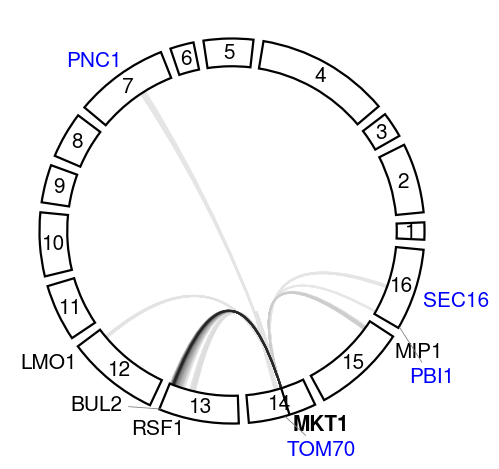

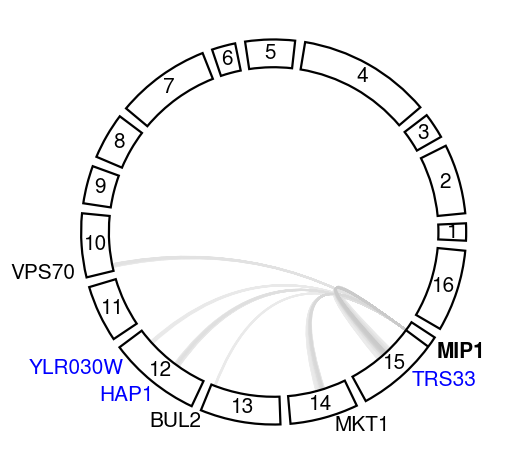

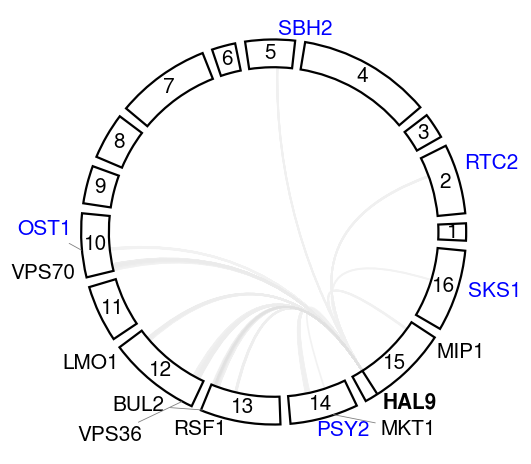

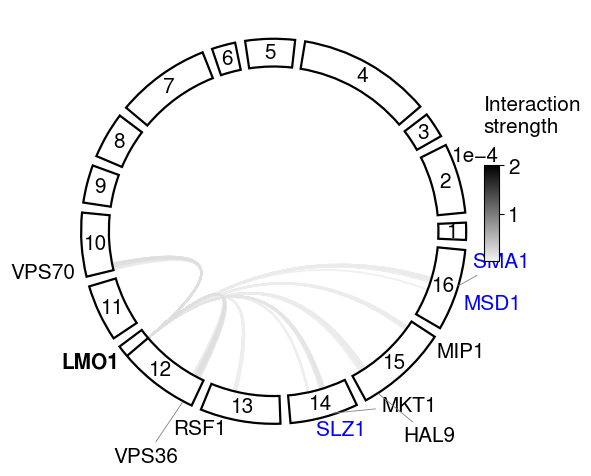

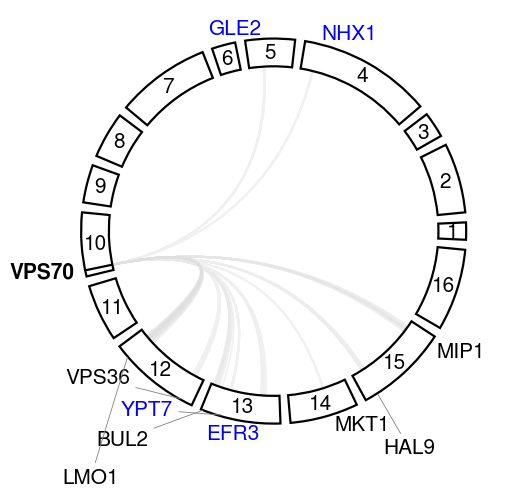

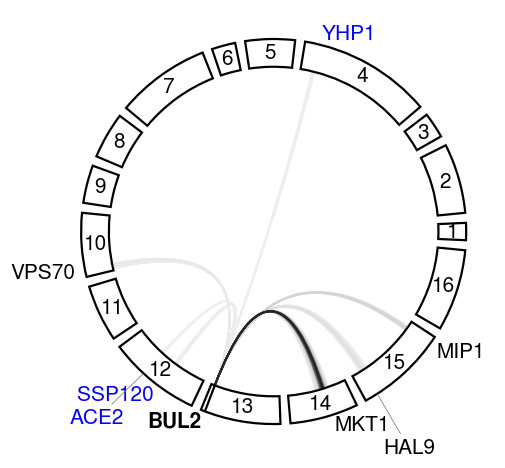

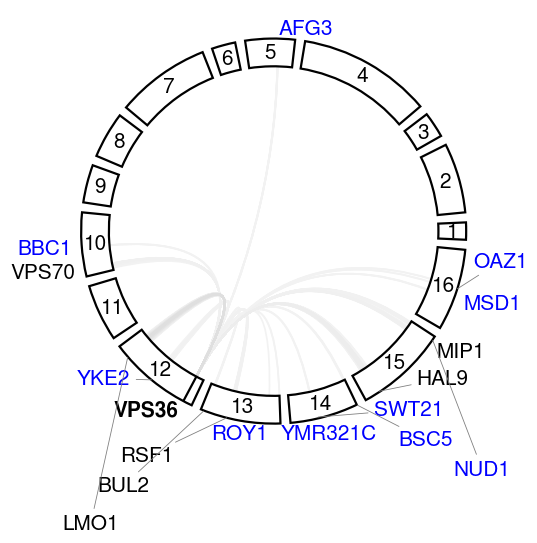

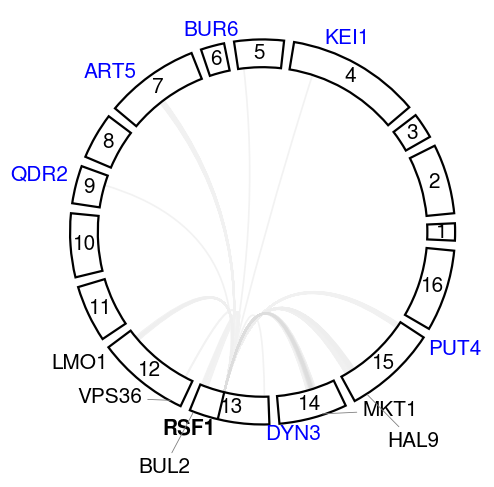

In [30]:
plt.rcParams["font.family"] = "Nimbus Sans"

import importlib
import yeast_analysis.gene_circos
importlib.reload(yeast_analysis.gene_circos)
from yeast_analysis.gene_circos import plot_gene_circos


for hub in hub_list:
    if hub == 'LMO1':
        show_colorbar = True
    else:
        show_colorbar = False
        
    fig, ax, links = plot_gene_circos(
        "gene_info.csv",
        df_hub_interactions,
        gene_focal=hub,
        top_n=200,
        vmax=2e-4,
        vmin=threshold,
        ld_sampler=sampler,
        ld_threshold=0.5,
        hub_list=hub_list,
        # ribbon_color="#FFC04C",
        # ribbon_color='#805500',
        ribbon_color='black',
        nonhub_label_color="blue",
        ring_width=0.16,
        figsize=(6, 6),
        font_family="Nimbus Sans",
        font_weight="normal",       # Or "bold"
        label_fontsize=15,
        colorbar_tick_fontsize=15,    
        show_colorbar=show_colorbar, 
        gene_focal_fontweight="bold",
        gene_focal_color="black",
        
    )
    plt.savefig(fig_path + f"hub_interaction_{hub}.pdf", bbox_inches='tight')

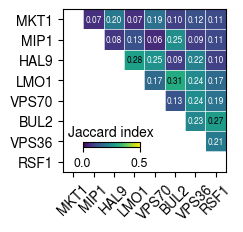

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

k = 200
df_plot = df_hub_interactions.iloc[:, :-1].copy()

if not df_plot.index.is_unique or not df_plot.columns.is_unique:
    raise ValueError("Gene names and hub columns must be unique.")

# Select each hub's top k partners.
# Ties are resolved by their existing row order.
top_genes = {}
for hub in df_plot.columns:
    scores = pd.to_numeric(df_plot[hub], errors="raise")
    scores = scores.drop(index=hub, errors="ignore")
    scores = scores.replace([np.inf, -np.inf], np.nan).dropna()
    top_genes[hub] = set(
        scores.sort_values(ascending=False, kind="stable").head(k).index
    )

# Pairwise Jaccard similarity.
hubs = df_plot.columns
jaccard = pd.DataFrame(np.nan, index=hubs, columns=hubs)

for i, hub_a in enumerate(hubs):
    for j in range(i, len(hubs)):
        hub_b = hubs[j]
        a, b = top_genes[hub_a], top_genes[hub_b]
        union = a | b
        value = len(a & b) / len(union) if union else np.nan
        jaccard.iloc[i, j] = jaccard.iloc[j, i] = value

fig, ax = plt.subplots(figsize=(2.5, 2.5))

# Jaccard ranges from 0 (no overlap) to 1 (identical sets).
norm = Normalize(vmin=0, vmax=.5)
cmap = plt.get_cmap("viridis")

n_cols = len(hubs)
mask = np.tril(np.ones((n_cols, n_cols), dtype=bool))
masked_data = np.ma.masked_invalid(
    np.ma.masked_array(jaccard.to_numpy(), mask=mask)
)

im = ax.imshow(masked_data, cmap=cmap, norm=norm, aspect="equal")

ax.set_xticks(np.arange(n_cols))
ax.set_yticks(np.arange(n_cols))
ax.set_xticklabels(hubs, rotation=45, ha="center", fontsize=10)
ax.set_yticklabels(hubs, fontsize=10)

for i in range(n_cols + 1):
    ax.axhline(i - 0.5, color="white", linewidth=0.5)
    ax.axvline(i - 0.5, color="white", linewidth=0.5)

for i in range(n_cols):
    for j in range(i + 1, n_cols):
        value = jaccard.iloc[i, j]
        if pd.isna(value):
            continue

        r, g, b, _ = cmap(norm(value))
        luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
        ax.text(
            j, i, f"{value:.2f}",
            ha="center", va="center",
            color="black" if luminance > 0.5 else "white",
            fontsize=6,
        )

fig.tight_layout()

# cax = inset_axes(
#     ax, width="3%", height="30%",
#     loc="lower left", borderpad=0.5,
# )
cax = ax.inset_axes([0.12, 0.15, 0.35, 0.035])

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
)

cbar.set_label("Jaccard index", fontsize=10)
cbar.set_ticks([0, 0.5])
cbar.ax.tick_params(labelsize=9)
cbar.solids.set_rasterized(False)

cbar.ax.xaxis.set_label_position("top")
cbar.ax.xaxis.set_ticks_position("bottom")

fig.savefig(
    fig_path + "jaccard_top100_heatmap.pdf",
    dpi=300, bbox_inches="tight",
)

# print("Genes selected per hub:")
# print(pd.Series({hub: len(genes) for hub, genes in top_genes.items()}))
# print("\nJaccard similarity matrix:")
# print(jaccard)

plt.show()

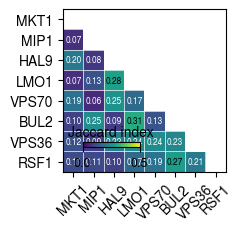

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

k = 200
df_plot = df_hub_interactions.iloc[:, :-1].copy()

if not df_plot.index.is_unique or not df_plot.columns.is_unique:
    raise ValueError("Gene names and hub columns must be unique.")

# Select each hub's top k partners.
# Ties are resolved by their existing row order.
top_genes = {}

for hub in df_plot.columns:
    scores = pd.to_numeric(df_plot[hub], errors="raise")
    scores = scores.drop(index=hub, errors="ignore")
    scores = scores.replace([np.inf, -np.inf], np.nan).dropna()

    top_genes[hub] = set(
        scores.sort_values(
            ascending=False,
            kind="stable"
        ).head(k).index
    )


# Pairwise Jaccard similarity.
hubs = df_plot.columns
jaccard = pd.DataFrame(
    np.nan,
    index=hubs,
    columns=hubs
)

for i, hub_a in enumerate(hubs):
    for j in range(i, len(hubs)):

        hub_b = hubs[j]

        a = top_genes[hub_a]
        b = top_genes[hub_b]

        union = a | b

        value = (
            len(a & b) / len(union)
            if union else np.nan
        )

        jaccard.iloc[i, j] = value
        jaccard.iloc[j, i] = value


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(2.5, 2.5))

# Jaccard ranges from 0 (no overlap) to 1 (identical sets).
norm = Normalize(vmin=0, vmax=0.5)
cmap = plt.get_cmap("viridis")

n_cols = len(hubs)


# Mask upper triangle + diagonal,
# leaving only the LOWER triangle visible.
mask = np.triu(
    np.ones((n_cols, n_cols), dtype=bool)
)

masked_data = np.ma.masked_invalid(
    np.ma.masked_array(
        jaccard.to_numpy(),
        mask=mask
    )
)


im = ax.imshow(
    masked_data,
    cmap=cmap,
    norm=norm,
    aspect="equal"
)


# Axis labels
ax.set_xticks(np.arange(n_cols))
ax.set_yticks(np.arange(n_cols))

ax.set_xticklabels(
    hubs,
    rotation=45,
    ha="center",
    fontsize=10
)

ax.set_yticklabels(
    hubs,
    fontsize=10
)


# Grid lines
for i in range(n_cols + 1):

    ax.axhline(
        i - 0.5,
        color="white",
        linewidth=0.5
    )

    ax.axvline(
        i - 0.5,
        color="white",
        linewidth=0.5
    )


# Annotate LOWER triangle
for i in range(n_cols):

    for j in range(i):

        value = jaccard.iloc[i, j]

        if pd.isna(value):
            continue

        r, g, b, _ = cmap(norm(value))

        luminance = (
            0.2126 * r
            + 0.7152 * g
            + 0.0722 * b
        )

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color=(
                "black"
                if luminance > 0.5
                else "white"
            ),
            fontsize=6,
        )


fig.tight_layout()


# ------------------------------------------------------------
# Horizontal colorbar
# ------------------------------------------------------------

cax = ax.inset_axes(
    [0.12, 0.15, 0.35, 0.035]
)

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
)

cbar.set_label(
    "Jaccard index",
    fontsize=10
)

cbar.set_ticks([0, 0.5])

cbar.ax.tick_params(
    labelsize=9
)

cbar.solids.set_rasterized(False)

cbar.ax.xaxis.set_label_position("top")
cbar.ax.xaxis.set_ticks_position("bottom")


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

fig.savefig(
    fig_path + "jaccard_top200_heatmap.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()